In [164]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jp
import tqdm
import jax_model
from flax import struct

In [156]:
import importlib; importlib.reload(jax_model)

<module 'jax_model' from '/home/emil/Development/torque-lever-simulation/jax_model.py'>

In [3]:
key = jax.random.key(seed=123)

In [4]:
sim = jax_model.TorqueLeverSimulationJAX(
    lever_mass = 3.5e-3,    #kg
    lever_length = 15e-2,   #meter
    lever_range = (30, 100), #degrees
    motor_baseline_torque = 3e-3,
    motor_extra_torque = 2e-2,
    motor_onset_angle = (75, 80),
    friction_coeff = 0.0e-3,
    dt=1e-3
)

In [ ]:
tt = jp.linspace(0, 1, 500)
true_force = -jp.sin(4*tt)**2*tt - 0.1*tt**2
true_theta = sim.run(true_force)

In [7]:
mean_force = -0.5*jp.ones(500)
mean_theta = sim.run(mean_force)
key = jax.random.key(seed=123)

In [425]:
@struct.dataclass
class MCMCState:
    raw_forces: jax.Array
    loglikelihood: jax.Array
    theta: jax.Array

def add_noise(sim, key, raw_forces, log_ampl, noise_sigma, S, S_inv):
    k1, k2 = jax.random.split(key)
    ampl = jp.exp(log_ampl * jax.random.normal(k1, (1000,)))
    raw_forces = raw_forces + ampl[:, None] * jax.random.multivariate_normal(k2, jp.zeros(500), S, (1000,))
    forces = -jax.nn.softplus(raw_forces)
    theta = jax.vmap(sim.run)(forces)
    ll = compute_ll(sim, raw_forces, forces, theta, noise_sigma, S_inv)
    return MCMCState(raw_forces, ll, theta)

def init_state(sim, key, log_ampl, noise_sigma, S, S_inv):
    return add_noise(sim, key, -2.0, log_ampl, noise_sigma, S, S_inv)

def gp_cov_mat(bw=25.0): #Gaussian process covariance with bandwith bw
    xx, yy = jp.meshgrid(jp.arange(500), jp.arange(500))
    S = (jp.exp(-((xx-yy)/bw)**2) + 1e-5*jp.eye(500))
    return S

def compute_ll(sim, raw_force, force, theta, noise_sigma, S_inv):
    ll = jp.sum((theta - true_theta)**2, axis=1) / (noise_sigma**2)
    #ll += 0.5 * jax.vmap(lambda f: f @ S_inv @ f)(force)
    ll += 0.5 * jp.sum((force-(-0.2))**2, axis=1) / (0.1**2)
    ll -= jp.sum(jax.nn.log_sigmoid(raw_force), axis=1)
    return ll

def mc_update(sim, key, mcmc_state, log_ampl, noise_sigma, S, S_inv):
    key_prop, key_acc = jax.random.split(key)
    candidates = add_noise(sim, key_prop, mcmc_state.raw_forces, log_ampl, noise_sigma, S, S_inv)
    alpha = jp.minimum(1.0, jp.exp(-(candidates.loglikelihood - mcmc_state.loglikelihood)))
    acc = jax.random.uniform(key_acc, alpha.shape) < alpha
    new_state = jax.tree.map(lambda new,old: jp.where(acc.reshape((-1,) + (1,) * (new.ndim - 1)), new, old), candidates, mcmc_state)
    log_ampl = log_ampl + 0.1 * (acc - 0.234)
    mean_err = jp.sqrt(jp.mean((new_state.theta - true_theta)**2))
    return new_state, log_ampl, acc.mean(), mean_err
mc_update = jax.jit(mc_update, static_argnums=0)

In [426]:
S = gp_cov_mat(25.0)
S_inv = jp.linalg.inv(S)
log_ampl = jp.ones(1000)
state = init_state(sim, key, log_ampl, 0.002, S, S_inv)
acc_history = []
mean_err_history = []
mean_ll_history = []
for step in tqdm.trange(2500):
    state, log_ampl, mean_acc, mean_err = mc_update(sim, jax.random.fold_in(key, step), state, log_ampl, 0.002, S, S_inv)
    acc_history.append(mean_acc)
    mean_err_history.append(mean_err)

100%|██████████| 2500/2500 [00:06<00:00, 365.43it/s]


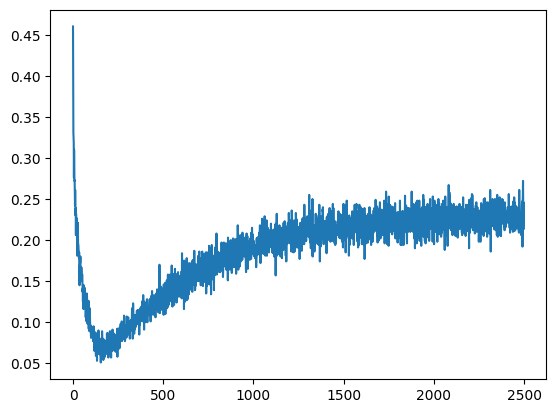

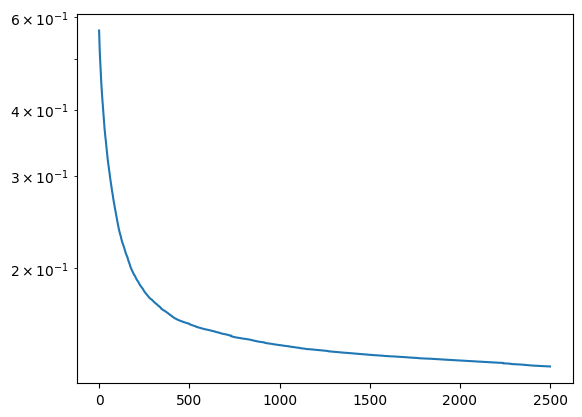

In [427]:
plt.plot(acc_history)
plt.show()
plt.semilogy(mean_err_history)
plt.show()

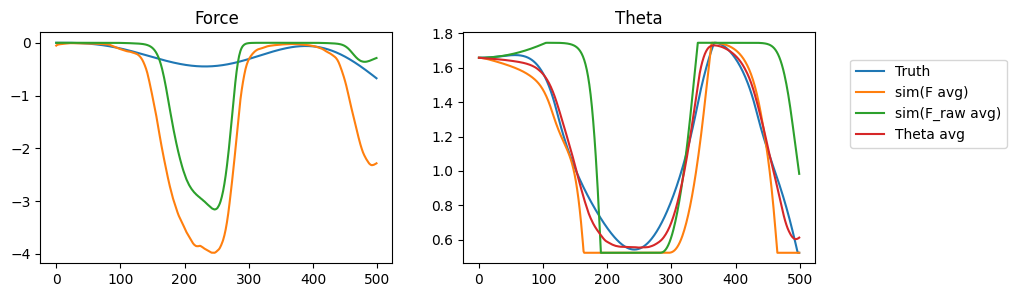

In [428]:
F = -jax.nn.softplus(state.raw_forces).mean(axis=0)
F_m = -jax.nn.softplus(state.raw_forces.mean(axis=0))
pred_theta = state.theta.mean(axis=0)
theta_F = sim.run(F)
theta_F_m = sim.run(F_m)

fig, axs = plt.subplots(1,2,figsize=(10, 3))
axs[0].set_title("Force")
axs[0].plot(true_force, label="Truth")
axs[0].plot(F, label="Prediction (F avg)")
axs[0].plot(F_m, label="Prediction (F_raw avg)")
axs[1].set_title("Theta")
axs[1].plot(true_theta, label="Truth")
axs[1].plot(theta_F, label="sim(F avg)")
axs[1].plot(theta_F_m, label="sim(F_raw avg)")
axs[1].plot(pred_theta, label="Theta avg")
axs[1].legend(loc=(1.1, 0.5))
plt.show()

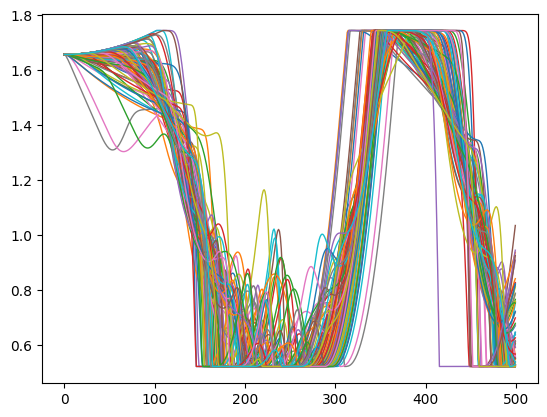

In [429]:
for i in range(100):
    plt.plot(state.theta[i], lw=1)
plt.show()

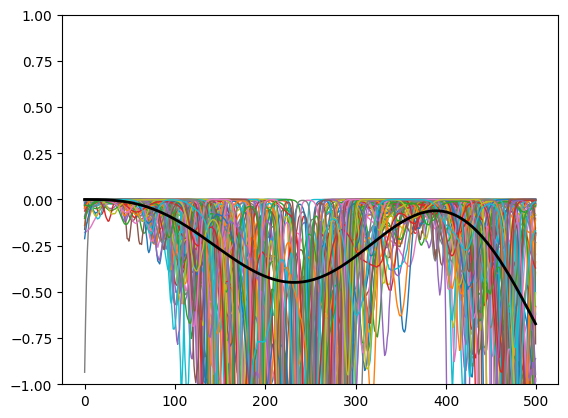

In [430]:
F = -jax.nn.softplus(state.raw_forces)
for i in range(100):
    plt.plot(F[i], lw=1)
plt.plot(true_force, 'k', lw=2)
plt.ylim(-1,1)
plt.show()

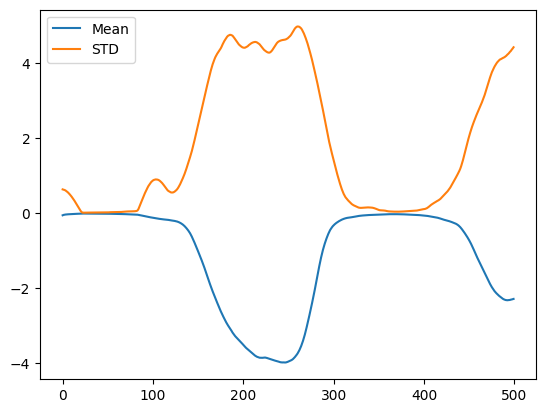

In [431]:
plt.plot(F.mean(axis=0), label="Mean")
plt.plot(F.std(axis=0), label="STD")
plt.legend()

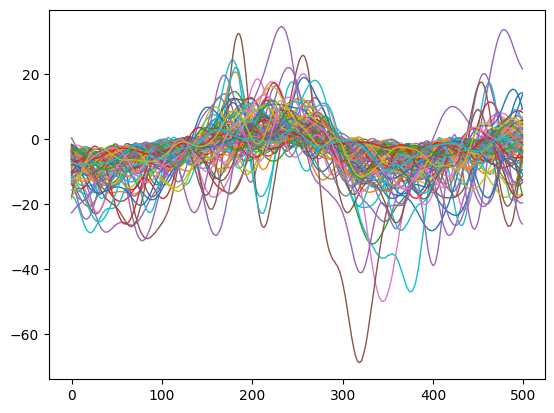

In [408]:
for i in range(100):
    plt.plot(state.raw_forces[i], lw=1)
plt.show()

In [424]:
jax.nn.softplus(2.0)

Array(2.126928, dtype=float32, weak_type=True)